# Intro to Deep Learning from Scratch in Julia

This notebook is a basic introduction to deep learning. The goal is not to use a high-level library immediately, but to see the core pieces clearly:

1. What deep learning does: learn an unknown function.  
2. What a neural network contains: parameters, linear transformations, activation functions, and layers.  
3. What training means: reduce prediction error.  
4. What backpropagation computes: gradients of the loss with respect to parameters.  
5. A small example: write Julia code from scratch to learn a nonlinear function.

## 1. Why should economists care about deep learning?

In many economic problems, the object we want is an unknown function:

$$y = f(x).$$

Examples include:

- value function: $V(k, z)$
- policy function: $c(k, z)$ or $k'(k, z)$
- pricing kernel
- conditional expectation: $E[y \mid x]$
- classifier: map features into a class

Traditional methods choose a function class by hand, such as polynomials, Chebyshev polynomials, or splines. Deep learning uses a parameterized function $g_\theta(x)$ to approximate $f(x)$:

$$f(x) \approx g_\theta(x).$$

Training a neural network means choosing $\theta$ so that $g_\theta(x)$ is close to the observed data.

## 2. The key idea: change representation, then approximate

Deep learning is not only curve fitting. It also searches for a useful representation of the data.

Traditional function approximation is often written as:

$$f(x) \approx h(x).$$

A neural network is closer to:

$$f(x) \approx g(\phi(x)).$$

Here:

- $x$ is the raw input.
- $\phi(x)$ is a representation learned by earlier layers.
- $g(\cdot)$ uses that representation to predict the output.

In simple terms, the network bends, stretches, and combines the original variables into useful intermediate features, then predicts $y$ from those features.

## 3. Julia setup

We use basic Julia plus `Random`, `Statistics`, `LinearAlgebra`, and `Plots`. This keeps the internal steps visible.

In [14]:
using Pkg
 Pkg.activate(".")
 
 using Random
 using Statistics
 using LinearAlgebra
 using Plots
 
 default(size=(760, 430), linewidth=2, label=false)
 include("src/NetworkDiagram.jl")

  Activating project at `c:\Users\86132\Desktop\Yuxuan ZHAO\minnesota\Research\DeepLearningMacro`


plot_intro_network_diagram

## 4. A small task: learn an unknown function

Suppose the true function is:

$$f(x) = \sin(3x) + 0.3x^2.$$

For now, pretend we do not know this formula. We only observe data points $(x_i, y_i)$. We will train a neural network to learn the map $x \mapsto y$.

This is the basic supervised-learning regression problem.

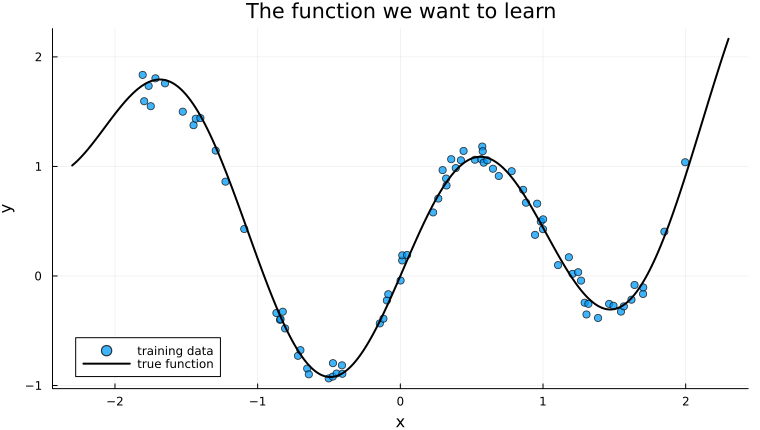

In [15]:
f_true(x) = sin(3x) + 0.3x^2

rng = MersenneTwister(123)
n_train = 80

x_train_vec = sort(4 .* rand(rng, n_train) .- 2)      # x in [-2, 2]
noise = 0.08 .* randn(rng, n_train)
y_train_vec = f_true.(x_train_vec) .+ noise

x_grid_vec = collect(range(-2.3, 2.3, length=300))
y_grid_true = f_true.(x_grid_vec)

scatter(x_train_vec, y_train_vec, markersize=4, alpha=0.75, label="training data")
plot!(x_grid_vec, y_grid_true, label="true function", color=:black)
xlabel!("x")
ylabel!("y")
title!("The function we want to learn")

## 5. Start with the simplest model: linear regression

The linear model is:

$$\hat y = a + bx.$$

Here $a$ and $b$ are parameters. Training means choosing $a,b$ to minimize mean squared error:

$$L(a,b)=\frac{1}{N}\sum_{i=1}^N (a + bx_i - y_i)^2.$$

We first write gradient descent by hand.

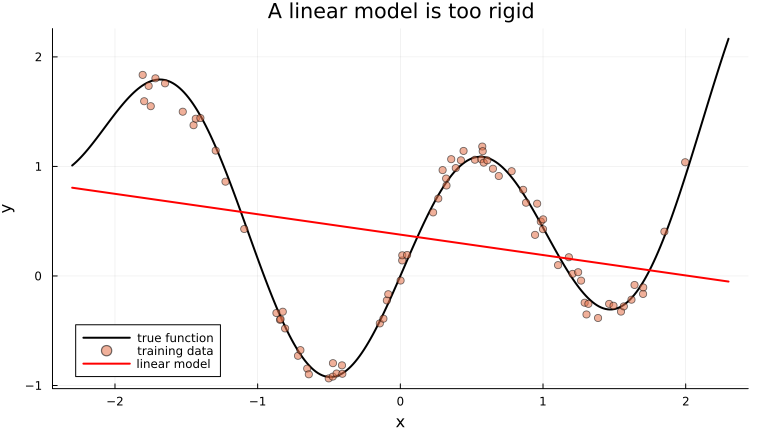

In [16]:
function fit_linear_gd(x, y; lr=0.03, epochs=2_000)
    a = 0.0
    b = 0.0
    losses = Float64[]
    n = length(x)

    for epoch in 1:epochs
        yhat = a .+ b .* x
        err = yhat .- y
        loss = mean(err .^ 2)

        da = 2 * mean(err)
        db = 2 * mean(err .* x)

        a -= lr * da
        b -= lr * db

        if epoch % 20 == 0
            push!(losses, loss)
        end
    end

    return a, b, losses
end

a_hat, b_hat, linear_losses = fit_linear_gd(x_train_vec, y_train_vec)
y_linear_grid = a_hat .+ b_hat .* x_grid_vec

plot(x_grid_vec, y_grid_true, label="true function", color=:black)
scatter!(x_train_vec, y_train_vec, markersize=4, alpha=0.55, label="training data")
plot!(x_grid_vec, y_linear_grid, label="linear model", color=:red)
xlabel!("x")
ylabel!("y")
title!("A linear model is too rigid")

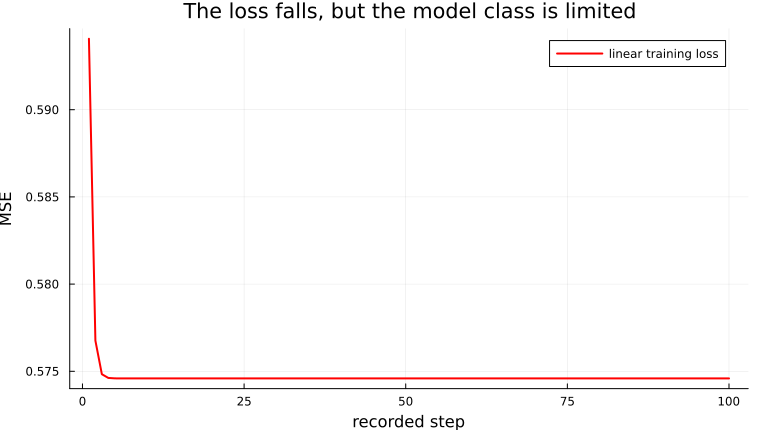

In [17]:
plot(linear_losses, label="linear training loss", color=:red)
xlabel!("recorded step")
ylabel!("MSE")
title!("The loss falls, but the model class is limited")

The linear model loss falls, but the model can only draw a straight line. The true function bends and oscillates, so a well-trained linear model still cannot represent it.

This is the basic idea of model capacity: if the model class is too simple, it cannot express the true function.

## 6. A minimal neural network

Now we use a neural network with one hidden layer:

$$z_1 = W_1x + b_1,$$

$$h = \tanh(z_1),$$

$$\hat y = W_2h + b_2.$$

Intuition:

- $W_1x+b_1$: create many different linear transformations of the input.
- $\tanh(\cdot)$: add nonlinear bending. Without nonlinearity, stacked linear layers are still linear.
- $W_2h+b_2$: combine intermediate features into the final prediction.

Here $h$ is a simple representation.

The diagram below shows the same architecture. The notebook later uses more hidden neurons for training, but the structure is the same.

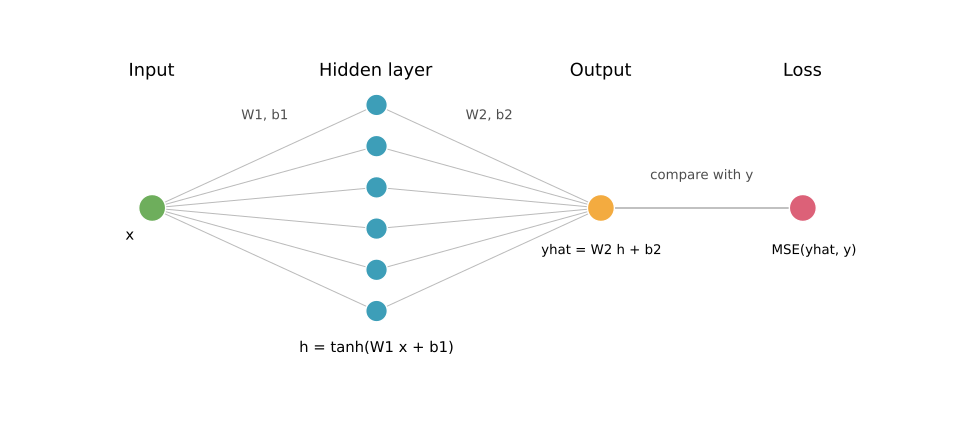

In [18]:
plot_intro_network_diagram(hidden=6)

In [19]:
# Neural-network code below expects observations in columns.
X_train = reshape(x_train_vec, 1, :)
Y_train = reshape(y_train_vec, 1, :)
X_grid = reshape(x_grid_vec, 1, :)

size(X_train), size(Y_train)

((1, 80), (1, 80))

In [20]:
function init_network(n_hidden; seed=1)
    rng = MersenneTwister(seed)
    return (
        W1 = 0.7 .* randn(rng, n_hidden, 1),
        b1 = zeros(n_hidden, 1),
        W2 = 0.7 .* randn(rng, 1, n_hidden),
        b2 = zeros(1, 1)
    )
end

function forward(p, X)
    Z1 = p.W1 * X .+ p.b1
    H = tanh.(Z1)
    Yhat = p.W2 * H .+ p.b2
    return Yhat, H, Z1
end

mse(Yhat, Y) = mean((Yhat .- Y) .^ 2)

p = init_network(12, seed=11)
Yhat0, H0, Z10 = forward(p, X_train)
mse(Yhat0, Y_train)

12.385602679805002

## 7. Backpropagation: chain rule for gradients

The training objective is still mean squared error:

$$L(\theta)=\frac{1}{N}\sum_{i=1}^N(\hat y_i-y_i)^2.$$

We need the effect of each parameter on the loss:

$$\frac{\partial L}{\partial W_1},\quad \frac{\partial L}{\partial b_1},\quad \frac{\partial L}{\partial W_2},\quad \frac{\partial L}{\partial b_2}.$$

Backpropagation is just the chain rule. Since:

$$x \rightarrow z_1 \rightarrow h \rightarrow \hat y \rightarrow L,$$

we start from $L$ and move backward layer by layer.

In [21]:
function gradients(p, X, Y)
    n = size(X, 2)
    Yhat, H, Z1 = forward(p, X)

    # dL/dYhat for mean squared error
    dYhat = (2 / n) .* (Yhat .- Y)

    # Yhat = W2 * H + b2
    dW2 = dYhat * H'
    db2 = sum(dYhat, dims=2)

    # H = tanh(Z1), so dH/dZ1 = 1 - tanh(Z1)^2 = 1 - H^2
    dH = p.W2' * dYhat
    dZ1 = dH .* (1 .- H .^ 2)

    # Z1 = W1 * X + b1
    dW1 = dZ1 * X'
    db1 = sum(dZ1, dims=2)

    return (W1=dW1, b1=db1, W2=dW2, b2=db2)
end

function update!(p, g, lr)
    p.W1 .-= lr .* g.W1
    p.b1 .-= lr .* g.b1
    p.W2 .-= lr .* g.W2
    p.b2 .-= lr .* g.b2
    return p
end

g = gradients(p, X_train, Y_train)
norm(g.W1), norm(g.W2)

(12.434811231677228, 10.53177758370351)

## 8. Train the network

Gradient descent updates parameters by:

$$\theta \leftarrow \theta - \eta \nabla_\theta L(\theta),$$

where $\eta$ is the learning rate. If it is too small, training is slow. If it is too large, training can become unstable.

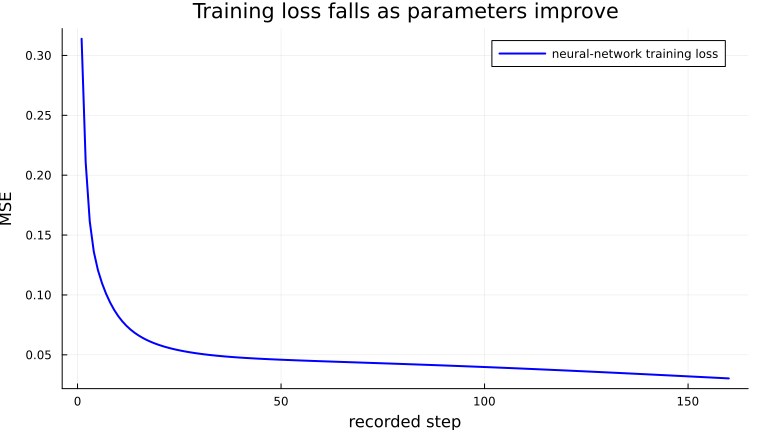

In [22]:
function train!(p, X, Y; lr=0.04, epochs=6_000, record_every=50)
    losses = Float64[]

    for epoch in 1:epochs
        g = gradients(p, X, Y)
        update!(p, g, lr)

        if epoch % record_every == 0
            Yhat, _, _ = forward(p, X)
            push!(losses, mse(Yhat, Y))
        end
    end

    return losses
end

p = init_network(24, seed=7)
nn_losses = train!(p, X_train, Y_train; lr=0.035, epochs=8_000, record_every=50)

plot(nn_losses, label="neural-network training loss", color=:blue)
xlabel!("recorded step")
ylabel!("MSE")
title!("Training loss falls as parameters improve")

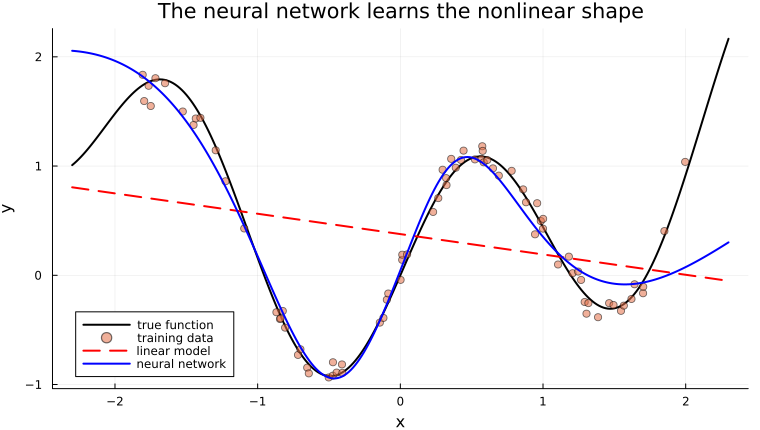

In [23]:
y_nn_grid = vec(first(forward(p, X_grid)))

plot(x_grid_vec, y_grid_true, label="true function", color=:black)
scatter!(x_train_vec, y_train_vec, markersize=4, alpha=0.55, label="training data")
plot!(x_grid_vec, y_linear_grid, label="linear model", color=:red, linestyle=:dash)
plot!(x_grid_vec, y_nn_grid, label="neural network", color=:blue)
xlabel!("x")
ylabel!("y")
title!("The neural network learns the nonlinear shape")

This figure shows the key ability of a neural network: it is not limited to straight lines. It can approximate complex functions by combining many nonlinear hidden units.

The intuition behind universal approximation is simple: with enough hidden units and a suitable activation function, even a basic feedforward network can approximate a wide class of functions.

## 9. What did the hidden layer learn?

Each hidden neuron creates an intermediate feature:

$$h_j(x)=\tanh(w_jx+b_j).$$

The final prediction is a weighted sum of these features:

$$\hat y = b_2 + \sum_j W_{2j}h_j(x).$$

This is the simplest version of representation learning.

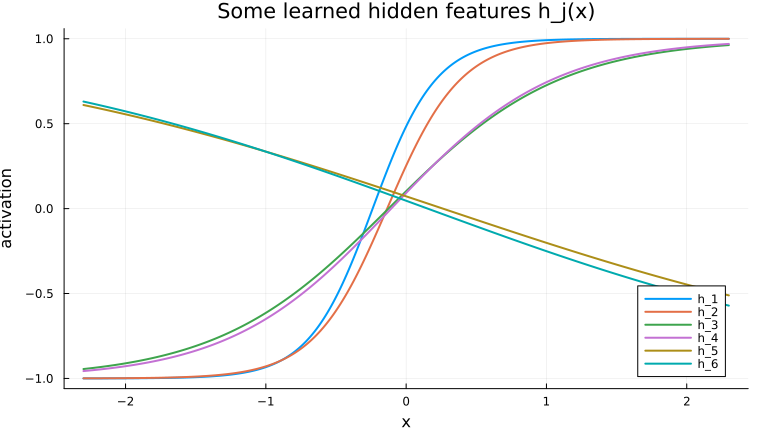

In [24]:
_, H_grid, _ = forward(p, X_grid)

plot(title="Some learned hidden features h_j(x)", xlabel="x", ylabel="activation")
for j in 1:6
    plot!(x_grid_vec, vec(H_grid[j, :]), label="h_$j")
end
plot!()

## 10. Model capacity: what if we add more hidden neurons?

More hidden neurons make the model more flexible. Flexibility is useful, but it is not automatically better:

- Too few: underfitting. The model cannot learn the true shape.
- Moderate: the model can fit while staying reasonably smooth.
- Too many: the model may chase noise. In practice, deep learning also uses regularization, dropout, early stopping, and more data.

Below we compare several hidden-layer sizes.

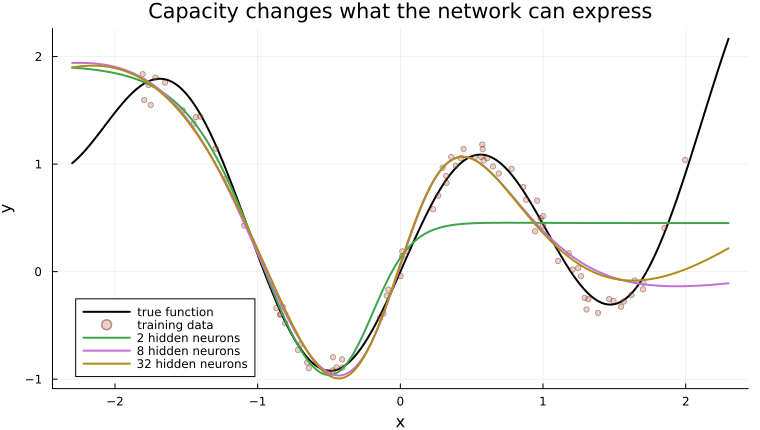

In [25]:
hidden_sizes = [2, 8, 32]
fits = Dict{Int, Vector{Float64}}()

for h in hidden_sizes
    p_h = init_network(h, seed=10 + h)
    train!(p_h, X_train, Y_train; lr=0.035, epochs=6_000, record_every=200)
    fits[h] = vec(first(forward(p_h, X_grid)))
end

plot(x_grid_vec, y_grid_true, label="true function", color=:black)
scatter!(x_train_vec, y_train_vec, markersize=3, alpha=0.35, label="training data")
for h in hidden_sizes
    plot!(x_grid_vec, fits[h], label="$h hidden neurons")
end
xlabel!("x")
ylabel!("y")
title!("Capacity changes what the network can express")

## 11. Why do activation functions matter?

Without activation functions, stacked linear transformations are still just one linear transformation. For example:

$$W_2(W_1x+b_1)+b_2 = (W_2W_1)x + (W_2b_1+b_2).$$

Nonlinear activations are what let neural networks express complex functions.

Common activation functions:

- sigmoid: $\sigma(z)=1/(1+e^{-z})$
- tanh: $\tanh(z)$
- ReLU: $\max(0,z)$
- softplus: $\log(1+e^z)$

Activations determine how the network bends and transforms the input space.

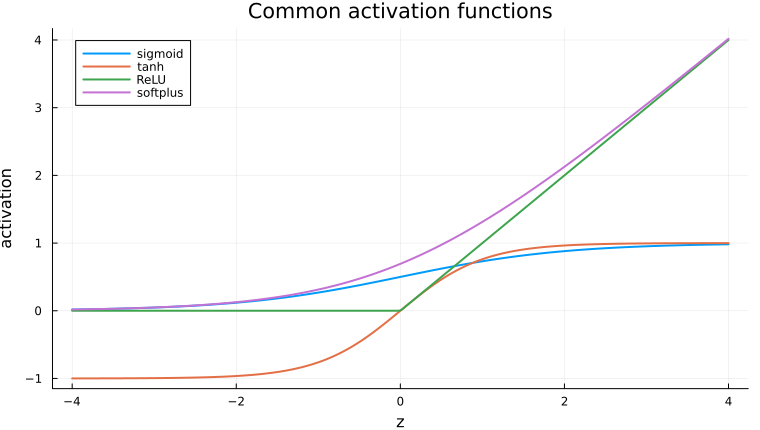

In [26]:
sigmoid(z) = 1 / (1 + exp(-z))
relu(z) = max(0, z)
softplus(z) = log1p(exp(z))

z = collect(range(-4, 4, length=300))
plot(z, sigmoid.(z), label="sigmoid")
plot!(z, tanh.(z), label="tanh")
plot!(z, relu.(z), label="ReLU")
plot!(z, softplus.(z), label="softplus")
xlabel!("z")
ylabel!("activation")
title!("Common activation functions")

## 12. Training error is not enough: test on new points

During training, the network only sees the training points. A lower training loss means the network fits those points better, but it does not prove that the network has learned the underlying function.

The usual check is to create a **test set**:

- training set: points used to update the parameters.
- test set: new points not used during training.

After training is finished, we freeze the parameters and predict on the test set. If test MSE is also low, the network is probably learning the function rather than only memorizing the training data.

In this toy example, we know the true data-generating function, so we can create new test points ourselves. In real data work, we would hold out part of the observed data before training.

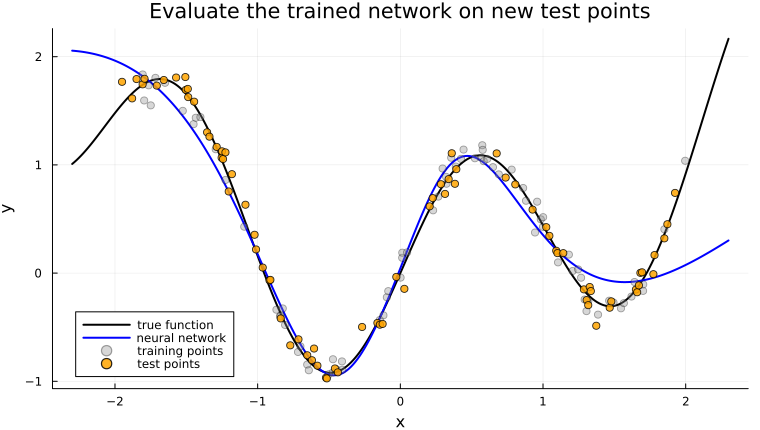

In [27]:
test_rng = MersenneTwister(456)
n_test = 80

# These points are new. They were not used when training the network.
x_test_vec = sort(4 .* rand(test_rng, n_test) .- 2)
test_noise = 0.08 .* randn(test_rng, n_test)
y_test_vec = f_true.(x_test_vec) .+ test_noise
X_test = reshape(x_test_vec, 1, :)

y_test_nn = vec(first(forward(p, X_test)))

plot(x_grid_vec, y_grid_true, label="true function", color=:black)
plot!(x_grid_vec, y_nn_grid, label="neural network", color=:blue)
scatter!(x_train_vec, y_train_vec, markersize=4, alpha=0.35, label="training points", color=:gray55)
scatter!(x_test_vec, y_test_vec, markersize=4, alpha=0.85, label="test points", color=:orange)
xlabel!("x")
ylabel!("y")
title!("Evaluate the trained network on new test points")

Now compare MSE on the points used for training and on the new test points.

A useful rule of thumb:

- low train MSE and low test MSE: good fit and good generalization.
- low train MSE but high test MSE: likely overfitting.
- high train MSE and high test MSE: likely underfitting or poor training.

In [28]:
mse_vector(yhat, y) = mean((yhat .- y) .^ 2)

y_train_nn = vec(first(forward(p, X_train)))
y_train_linear = a_hat .+ b_hat .* x_train_vec
y_test_linear = a_hat .+ b_hat .* x_test_vec

metrics = (
    linear_train_mse = mse_vector(y_train_linear, y_train_vec),
    linear_test_mse = mse_vector(y_test_linear, y_test_vec),
    neural_network_train_mse = mse_vector(y_train_nn, y_train_vec),
    neural_network_test_mse = mse_vector(y_test_nn, y_test_vec),
    neural_network_clean_grid_mse = mse_vector(y_nn_grid, y_grid_true),
)

map(x -> round(x, digits=4), metrics)

(linear_train_mse = 0.5746, linear_test_mse = 0.5651, neural_network_train_mse = 0.0303, neural_network_test_mse = 0.0373, neural_network_clean_grid_mse = 0.2063)

The clean-grid MSE is not something we normally have in real data. We include it here only because this toy example knows the true function. It gives a direct check of how close the learned curve is to $f(x)$ over the whole interval.